# Inferring behavioral strategies during decision making using GLM-HMMs

In this notebook, we will show how to use choice data to derive hidden behavioral states using the NeMoS GLM-HMM implementation. We will use Nemos' Bernoulli GLM-HMM to model mice choices and extract their hidden behavioral states during a decision making task. As a result, we will replicate the previously published results from Ashwood et al. (2023). LINK REF

We have two main goals for this notebook:

1. How to use GLM-HMM to analyze real data / real world application.

    1.1 Showcase how to download and preprocess choice choice data to fit it with a GLM-HMM
2. Demonstrate how to replicate published results using NeMoS

Importantly, throughout the notebook we will assume you already have a solid theoretical understanding of GLMs and GLM-HMMs. If you need a refresher, please refer to our tutorial on GLMs and GLM-HMMs. Moreover, if you already have a good understanding of GLM-HMMs and are interested in different heuristics you could use to overcome difficulties in the fitting process, please refer to our tutorial for fine-grain details of the fitting algorithm and different initialization methods you could use to ensure the best possible fit and thus description of your data under this model.


## Very brief explanation of GLM-HMMs
- write graphical model, no math here?

## Setup

In [1]:
import nemos as nmo
from nemos.glm_hmm import GLMHMM

nmo.GLMHMM = GLMHMM

In [2]:
# Imports
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import nemos as nmo
import pynapple as nap
import seaborn as sns
from notebook_utils import *

seed = 0  # Random seed for reproducibility
np.random.seed(seed)
jax.config.update("jax_enable_x64", True)

# Parameters for plotting
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.5, rc=custom_params)#, context="notebook")

## Download and preprocessing of data
Normally, when importing an IBL dataset, you should follow this process:
XX
However, since we are interested in reproducing a particular set of figures, we will retrieve the already preprocessed data of a single mouse. If you are interested in understanding how this preprocessing took place, please refer to [ashwood's repo]

In [3]:
design_matrix, y_raw, session = load_data("IBL/CSHL_008_processed.npz")

'''
io = nmo.fetch.download_dandi_data(
    "000045/sub-00778394-c956-408d-8a6c-ca3b05a611d5",
    "sub-00778394-c956-408d-8a6c-ca3b05a611d5_ses-00594aec-bb70-4601-862d-63a31ef0e1c0_behavior+image.nwb"
)
'''

'\nio = nmo.fetch.download_dandi_data(\n    "000045/sub-00778394-c956-408d-8a6c-ca3b05a611d5",\n    "sub-00778394-c956-408d-8a6c-ca3b05a611d5_ses-00594aec-bb70-4601-862d-63a31ef0e1c0_behavior+image.nwb"\n)\n'

## 01. Understanding the task structure: IBL decision-making task

<center><img src="images/IBL_edited.png" alt="Task schematic" width="500" /></center>

<div style="text-align: center;">

  Task illustration. Modified from IBL et al. (2021) 
   <span id="cite1a"></span><a href="#ref1">[1a]</a>.
</div>

We will analyze the IBL decision-making task, which is a variation of the two-alternative forced-choice perceptual detection task (IBL et al., 2021 <span id="cite1b"></span><a href="#ref1">[1b]</a>). During this task, a sinusoidal grating with varying contrast [0\%-100\%] appeared either at the right or left side of the screen. The goal for the mice was to indicate this side turning a little wheel so that this turn would accordingly move the stimuli to the center of the screen (Burgess et al. (2021) <span id="cite2a"></span><a href="#ref2">[2]</a>. If the mice chose the side correctly, they would receive a water reward; if not, a noise burst and there would be a 1 second timeout. 

For the first 90 trials of each session, the stimulus appeared randomly on either side of the screen; after that, the stimulus would appear on one side with fixed probability 0.8 and alternate randomly every 20-100 trials. Same as in Ashwood et al., (2023)  <span id="cite1c"></span><a href="#ref1">[1c]</a>., we will only analyze the first 90 trials of each session (the ones with random appearance at either side).

First, let's see what the design matrix looks like. 

In [4]:
print(f"shape = {design_matrix.shape}")

shape = (5040, 3)


The design matrix has shape (n_timepoints, n_predictors). 
- PREDICTOR 1 - stimuli: grating contrast and position: the absolute value indicates the intensity of the contrast, whilst the sign indicates whether it was shown at the left (-) or the right (+) of the animal.
- PREDICTOR 2 - previous choice: choice made by the animal in the immediate previous timepoint - simply repeat the choice. The choice is coded by the sign: left (-) or right (+)
- PREDICTOR 3 - win-stay lose-shift: if the previous choice was rewarded, then repeat the choice; conversely, shift. Also coded with the sign: left (-) or right (+)

If the animal was engaged with the task, the only predictor that should be relevant is PREDICTOR 1 - stimuli

This will be followed by the preprocessing and at the end of the section we'd have a design matrix built w nemos & pynapple

In [5]:
print(f"input = {design_matrix}")    

input = [[-2.09318779e+00 -1.00000000e+00 -1.00000000e+00]
 [ 2.09541483e+00 -1.00000000e+00 -1.00000000e+00]
 [ 5.24688844e-01  1.00000000e+00  1.00000000e+00]
 ...
 [ 2.09541483e+00  1.00000000e+00 -1.00000000e+00]
 [ 1.11351692e-03  1.00000000e+00  1.00000000e+00]
 [ 1.32007349e-01  1.00000000e+00 -1.00000000e+00]]


In [6]:
# plot of task variables
X_mouse = design_matrix 

The choices are coded with 0 (choice left) and 1 (choice right)

In [7]:
# Choices
choices_mouse = y_raw.flatten() # Convert to (n_timepoints,) | maybe I should pass the data
print(set(choices_mouse))

{np.int64(0), np.int64(1)}


Importantly, do not do 3000 trials at once! Instead, they generally do several sessions of 100-300 trials, and we use all the sessions together to fit our model. For our model to be accurate, we need to tell it when our session boundaries are: we don't want it to compute two different sessions as if they were one. 

With NeMoS, we have two ways of indicating the beginning of a new session. When using a design matrix and a choice vector that are Numpy objects, NeMoS treats NaNs either in the input matrix X or in the choice vector y as new sessions. You can also use Pynapple objects to demarcate sessions, which is what we will use now.

!! careful, if your choice data contains nan values, they will be handled as new sessions, so make sure to address this promptly

In [8]:
# I would need to explain what the session array is above if I want to do this this way. I still am not super sure whether I want to do the data preprocessing here or not.

# new_sess array
# Create array of 1s and 0s marking session boundaries
new_sess_mouse = np.zeros(len(session), dtype=int)
new_sess_mouse[0] = 1  # First entry is always 1

# Mark where session changes
new_sess_mouse[1:] = (session[1:] != session[:-1]).astype(int)
new_sess_mouse

array([1, 0, 0, ..., 0, 0, 0], shape=(5040,))

Conversion to pynapple objects

admonition to send people to pynapple!

In [9]:
new_sess_pos = np.array(np.where(new_sess_mouse==1))
sess_length = np.array(np.where(new_sess_mouse==1))[0][1] - 1 # substracting the starting trial

choices_tsd = nap.Tsd(t = np.arange(choices_mouse.shape[0]), d=choices_mouse, time_support=nap.IntervalSet(start=new_sess_pos, end = new_sess_pos+ sess_length))

## Fitting a GLM-HMM with NeMoS (Maximum Likelihood)
The model:
- We are using a Bernoulli GLM, that is:
MATH

_math for it should be here, not explanation, just equations and an admonition to point them to more detailed notebooks_


First you need to initialize the object. The only mandatory thing you have to declare is the number of states which, in our case is 3. The default observation model for the GLM-HMM is this model is Bernoulli, but we also have Poisson, Gamma, Negative Binomial and Gaussian available. Moreover, if desired, you can also set a different observation model of your choice. You can also personalize the inverse link function.

! admonition on convexity non guaranteed for all likelihood functions, refer to Escola paper and also to the other notebook.

In [10]:
## Later remove
# True values
# True vars - to be used for plot generation 
# Initial guess - Initial prob
initial_prob_initial_guess_mouse = jnp.array([0.95, 0.025, 0.025])

true_intercept = np.array(
    [1, -3, 3],dtype=float  # Bias - Intercept
)
# Transition matrix
true_transition_prob = np.array(
    [[0.98, 0.01, 0.01], 
     [0.04, 0.94, 0.02], 
     [0.035, 0.005, 0.96]]
)

# True mouse projection weights
X_labels_mouse = ["bias", "stimulus", "Prev.choice", "WSLS"]

projection_weights_true_values_mouse = np.array(
    [
        [6, 2, 2],      # Stimulus,
        [-.1, .1, .2],  # Previous choice
        [-.1, .1, .2]  # Win-stay, lose-switch
        
    ]
    , dtype=float  
)
projection_weights_initial_guess_mouse = projection_weights_true_values_mouse

# True mouse intercept
intercept_initial_guess_mouse = true_intercept

true_transition_prob_mouse = true_transition_prob
transition_prob_initial_guess_mouse = true_transition_prob_mouse
# High proba in diagonal - low elsewhere
#transition_prob_initial_guess_mouse = np.ones(true_transition_prob.shape) * 0.05
#transition_prob_initial_guess_mouse[np.diag_indices(true_transition_prob.shape[1])] = 0.9



In [11]:
projection_weights_true_values_mouse.shape

(3, 3)

In [12]:
projection_weights_initial_guess_mouse

array([[ 6. ,  2. ,  2. ],
       [-0.1,  0.1,  0.2],
       [-0.1,  0.1,  0.2]])

In [13]:
## Inits from ashwood - these should be downloaded at the beginning of the notebook
b = np.load('best_global_params/best_params_K_3.npz', allow_pickle=True)
initial_prob_ashwood = np.exp(b["arr_0"][0]).squeeze(0)
transition_prob_ashwood = np.exp(b["arr_0"][1]).squeeze(0)
glm_weights_ashwood = np.asarray(-b["arr_0"][2])[:,:,:3].T.squeeze(1)
intercept_ashwood = np.asarray(-b["arr_0"][2])[:,:,3].T.squeeze(0)

initial_prob_initial_guess_mouse = initial_prob_ashwood
transition_prob_initial_guess_mouse = transition_prob_ashwood
projection_weights_initial_guess_mouse = glm_weights_ashwood
intercept_initial_guess_mouse = intercept_ashwood

Explain what a callable is - ie explain that the dictionary must contain functions

it was not intuitive how to set up the initialization values! it was a bit of a nightmare! is there no way to simply input the values?

In [14]:
n_states = 3
DESIGN_INPUT_TYPE = "Union[jnp.ndarray, FeaturePytree, nap.TsdFrame]"

from nemos.typing import Callable

def glm_params_funct(
    n_states: int, 
    X: DESIGN_INPUT_TYPE,
    y: jnp.ndarray, 
    inverse_link_function: Callable, 
    key: jax.random.PRNGKey, 
    glm_params_init = projection_weights_initial_guess_mouse, 
    intercept_init = intercept_initial_guess_mouse
): 
    return glm_params_init, intercept_initial_guess_mouse

def initial_proba_init_func(
    n_states: int, 
    X: DESIGN_INPUT_TYPE, 
    y: jnp.ndarray, 
    key: jax.random.PRNGKey, 
    initial_proba_init = initial_prob_initial_guess_mouse
): 
    return initial_proba_init

def transition_proba_init_func(
    n_states: int, 
    X: DESIGN_INPUT_TYPE, 
    y: jnp.ndarray, 
    key: jax.random.PRNGKey, 
    transition_proba_init = transition_prob_initial_guess_mouse
): 
    return transition_proba_init

init_dic = {
    "glm_params_init":glm_params_funct,  # Uniform initial state distribution
    "initial_proba_init": initial_proba_init_func,  # Random GLM weights
    "transition_proba_init": transition_proba_init_func,  # Initial noise variances,
    "scale_init" : "constant"
}

model = nmo.glm_hmm.GLMHMM(n_states, initialization_funcs=init_dic)
print(model)

GLMHMM(
    n_states=3,
    observation_model=BernoulliObservations(),
    inverse_link_function=logistic,
    regularizer=UnRegularized(),
    solver_name='GradientDescent[optimistix]',
    initialization_funcs={'glm_params_init': <function glm_params_funct at 0x11decd6c0>, 'scale_init': <function constant_scale_init at 0x11bf27ba0>, 'transition_proba_init': <function transition_proba_init_func at 0x11decd8a0>, 'initial_proba_init': <function initial_proba_init_func at 0x11dece160>},
    initialization_kwargs={'glm_params_init': {}, 'scale_init': {}, 'transition_proba_init': {}, 'initial_proba_init': {}},
    maxiter=1000,
    tol=1e-08
)


explain all the things it has inside

and then fit it. The fit function takes two mandatory arguments: the design matrix which we discussed above and the vector (or pynapple object) of neural activity or behavioral data(our case) you want to extract hidden states from. 

By default, the initialization algorithm for EM is the following[:]. However, you can also set the initial parameters of your choice.

! admonition on how to choose a good initialization of parameters
Probably point them to the other notebook

In [15]:
model.fit(X_mouse, choices_tsd)

,n_states,3
,observation_model,BernoulliObservations()
,inverse_link_function,<function log...t 0x11ba3aa20>
,regularizer,UnRegularized()
,regularizer_strength,None
,dirichlet_prior_alphas_init_prob,None
,dirichlet_prior_alphas_transition,None
,solver_name,'GradientDescent[optimistix]'
,solver_kwargs,{}
,initialization_funcs,"{'glm_params_init': <function glm...t 0x11decd6c0>, 'initial_proba_init': <function ini...t 0x11dece160>, 'scale_init': <function con...t 0x11bf27ba0>, 'transition_proba_init': <function tra...t 0x11decd8a0>}"
,initialization_kwargs,"{'glm_params_init': {}, 'initial_proba_init': {}, 'scale_init': {}, 'transition_proba_init': {}}"


We can retrieve different metrics after fitting, and we can see the full list using .get_params()

In [16]:
#model.get_params # stuff you can set when crossval

# parameters
# model.coef_
# mode.intercept_
# model.initial_prob_




If we want to see our glm-hmm parameters, we can call

In [17]:
model.coef_

Array([[ 6.48307752,  1.54135895,  1.58523934],
       [ 0.13703555, -0.30934056,  0.48165449],
       [ 0.08994439,  0.30139038,  0.30176862]], dtype=float64)

### Retrieved parameters

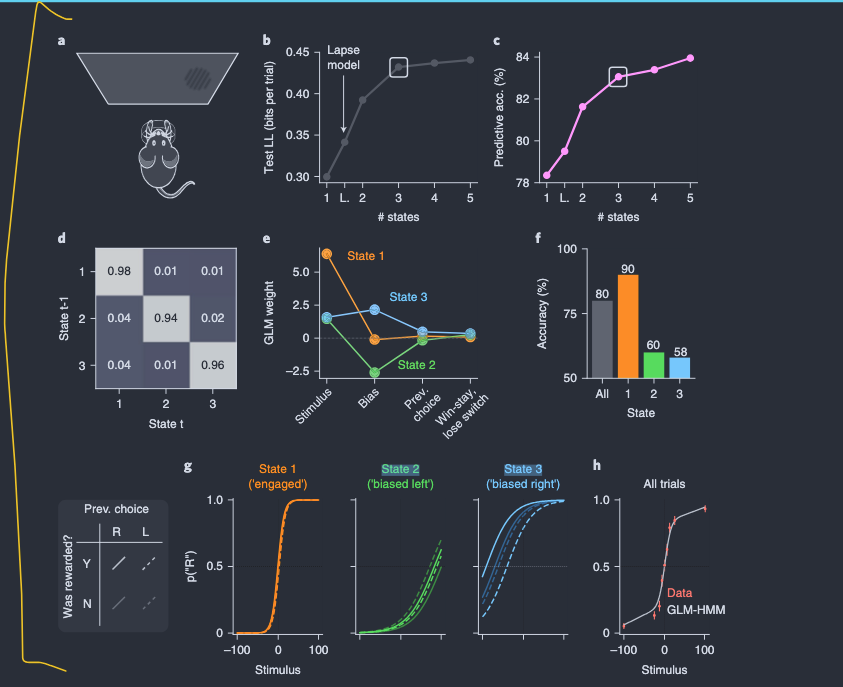

follow state descriptions in the paper
if you dont segment the paper then you would not be able to see some effects (see in what way they do that) -> explain at the very begining as a motivation and in the end as an interpretation -> why they thought to use this method

### Plot 2e: glm weights
90%

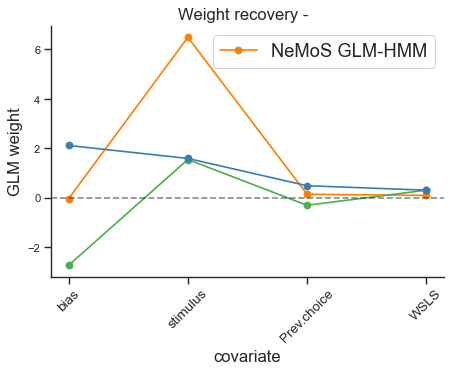

In [33]:
def plot_glm_weights(
    n_features,
    n_states,
    true_projection_weights,
    learned_intercept,
    learned_coef,
    X_labels,
    initialization_setting,
):
    ## Plot
    fig = plt.figure(figsize=(6, 5), dpi=80, facecolor="w", edgecolor="k")
    cols = ["#ff7f00", "#4daf4a", "#377eb8"]
    recovered_weights = np.zeros_like(true_projection_weights)

    recovered_weights[:1] = learned_intercept
    recovered_weights[1:] = learned_coef

    for k in range(n_states):
        if k == 0:
            #plt.plot(
            #    range(n_features),
            #    true_projection_weights[:, k],
            #    marker="o",
            #    color=cols[k],
            #    linestyle="-",
            #    lw=1.5,``
            #    label="Ashwood et al. (2022)",
            #)
            plt.plot(
                range(n_features),
                recovered_weights[:, k],
                marker="o",
                color=cols[k],
                lw=1.5,
                label="NeMoS GLM-HMM",
                linestyle="-",
            )
        else:
            #plt.plot(
            #    range(n_features),
            #    true_projection_weights[:, k],
            #    marker="o",
            #    color=cols[k],
            #    linestyle="-",
            #    lw=1.5,
            #    label="",
            #)

            plt.plot(
                range(n_features),
                recovered_weights[:, k],
                color=cols[k],
                marker="o",
                lw=1.5,
                label="",
                linestyle="-",
            )
            
    
    plt.yticks(fontsize=10)
    plt.ylabel("GLM weight", fontsize=15)
    plt.xlabel("covariate", fontsize=15)
    plt.xticks([i for i in range(n_features)], X_labels, fontsize=12, rotation=45)
    plt.axhline(y=0, color="k", alpha=0.5, ls="--")
    plt.legend()
    plt.title(f"Weight recovery - {initialization_setting}", fontsize=15)
    plt.tight_layout()
    plt.savefig("figures/fig_07_glm_hmm_behavioral.png")

    plt.show()
    return None

# Stack array for plotting
stacked_arr = np.vstack([true_intercept, projection_weights_true_values_mouse])
stacked_arr

plot_glm_weights(
    model.coef_.shape[0]+ 1,
    3, # n states
    stacked_arr,
    model.intercept_,
    model.coef_,
    X_labels_mouse,
    " ",
    )


### Plot 2d: transition matrix

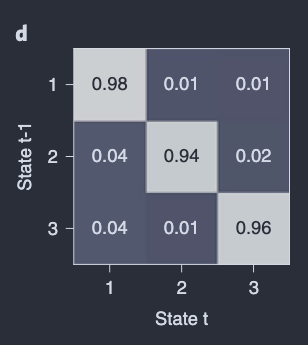\
Pending:
- Replace provisionary initialization with final values (until cluster finishes)


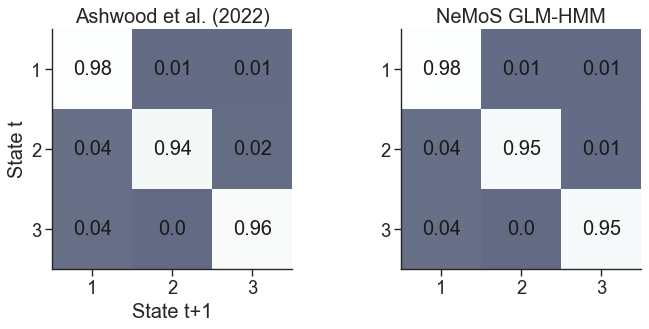

In [20]:
n_decimals = 2

fig = plt.figure(figsize=(8, 3), dpi=80, facecolor='w', edgecolor='k')
plt.subplot(1, 2, 1)
gen_trans_mat = true_transition_prob_mouse
plt.imshow(gen_trans_mat, vmin=-0.8, vmax=1, cmap='bone')
for i in range(gen_trans_mat.shape[0]):
    for j in range(gen_trans_mat.shape[1]):
        text = plt.text(j, i, str(np.around(gen_trans_mat[i, j], decimals=n_decimals)), ha="center", va="center",
                        color="k")
plt.xlim(-0.5, n_states - 0.5)
plt.xticks(range(0, n_states), ('1', '2', '3'))
plt.yticks(range(0, n_states), ('1', '2', '3'))
plt.ylim(n_states - 0.5, -0.5)
plt.ylabel("State t",)
plt.xlabel("State t+1")
plt.title("Ashwood et al. (2022)")


plt.subplot(1, 2, 2)
recovered_trans_mat = model.transition_prob_
plt.imshow(recovered_trans_mat, vmin=-0.8, vmax=1, cmap='bone')


for i in range(recovered_trans_mat.shape[0]):
    for j in range(recovered_trans_mat.shape[1]):
        text = plt.text(j, i, str(np.around(recovered_trans_mat[i, j], decimals=n_decimals))[:n_decimals+2], ha="center", va="center",
                        color="k")
plt.xlim(-0.5, n_states - 0.5)
plt.xticks(range(0, n_states), ('1', '2', '3'))
plt.yticks(range(0, n_states), ('1', '2', '3'))
plt.ylim(n_states - 0.5, -0.5)
plt.title("NeMoS GLM-HMM")
plt.subplots_adjust(0, 0, 1, 1)

### Plot 2g: Psychometric curves
To understand how different states "affect" (change wording) choice behavior, we can use a psychometric curve.

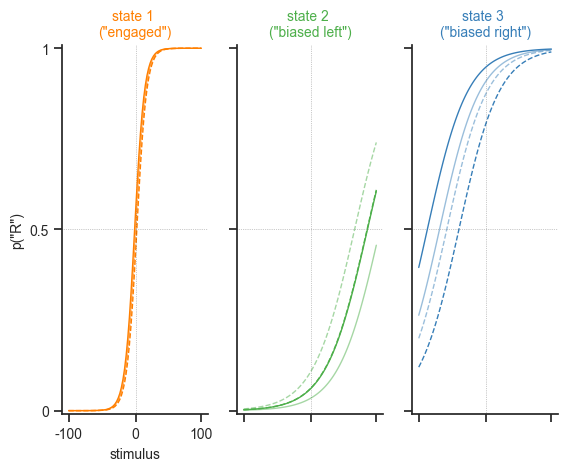

In [21]:
from scipy.special import expit
from nemos.glm_hmm.utils import compute_rate_per_state

class PARAMS:
    def __init__(self, coef, intercept):
        self.coef = coef
        self.intercept = intercept
param = PARAMS(model.coef_, model.intercept_)

def get_prob_right(model, inpt, k, pc, wsls):
    # pending to make this more elegant with NeMoS
    # stim vector
    min_val_stim = np.min(inpt[:, 0])
    max_val_stim = np.max(inpt[:, 0])
    
    stim_vals = np.arange(min_val_stim, max_val_stim, 0.05)
    
    # create input matrix - cols are stim, pc, wsls, bias
    x = np.array([
        stim_vals,
        np.repeat(pc, len(stim_vals)),
        np.repeat(wsls, len(stim_vals)),
    ]).T        
    
    return stim_vals, compute_rate_per_state(x, param, model.inverse_link_function)[:,k] #expit(wx)

stim_vals, prob_right_max  = get_prob_right(model, design_matrix, 0, 1, 1)
_, prob_right_min  = get_prob_right(model, design_matrix, 0, -1, -1)

cols = [
        '#ff7f00', '#4daf4a', '#377eb8', '#f781bf', '#a65628', '#984ea3',
        '#999999', '#e41a1c', '#dede00'
]
K = 3
for k in range(K):
    plt.subplot(1, 3, k+1)
    # USE GLM WEIGHTS TO GET PROB RIGHT
    stim_vals, prob_right_max = get_prob_right(model, design_matrix, k, 1, 1)
    _, prob_right_min = get_prob_right(model, design_matrix, k, -1, -1)
    
    plt.plot(stim_vals,
                prob_right_max,
                '-',
                color=cols[k],
                alpha=1,
                lw=1,
                zorder=5)  # went R and was rewarded on previous trial
    
    plt.plot(stim_vals,
                get_prob_right(model, design_matrix, k, -1, 1)[1],
                '--',
                color=cols[k],
                alpha=0.5,
                lw=1)  # went L and was not rewarded on previous trial
    plt.plot(stim_vals,
                get_prob_right(model, design_matrix, k, 1, -1)[1],
                '-',
                color=cols[k],
                alpha=0.5,
                lw=1,
                markersize=3)  # went R and was not rewarded on previous trial
    
    plt.plot(stim_vals, prob_right_min, '--', color=cols[k], alpha=1,
                lw=1)  # went L and was rewarded on previous trial
    
    plt.xticks([min(stim_vals), 0, max(stim_vals)],
                labels=['', '', ''],
                fontsize=10)
    
    plt.yticks([0, 0.5, 1], ['', '', ''], fontsize=10)
    plt.ylabel('')
    plt.xlabel('')
    if k == 0:
        plt.title("state 1 \n(\"engaged\")", fontsize=10, color=cols[k])
        plt.xticks([min(stim_vals), 0, max(stim_vals)],
                    labels=['-100', '0', '100'],
                    fontsize=10)
        plt.yticks([0, 0.5, 1], ['0', '0.5', '1'], fontsize=10)
        plt.ylabel('p("R")', fontsize=10)
        plt.xlabel('stimulus', fontsize=10)
    if k == 1:
        plt.title("state 2 \n(\"biased left\")",
                    fontsize=10,
                    color=cols[k])
        plt.xticks([min(stim_vals), 0, max(stim_vals)],
                    labels=['', '', ''],
                    fontsize=10)
        plt.yticks([0, 0.5, 1], ['', '', ''], fontsize=10)
    if k == 2:
        plt.title("state 3 \n(\"biased right\")",
                    fontsize=10,
                    color=cols[k])
        plt.xticks([min(stim_vals), 0, max(stim_vals)],
                    labels=['', '', ''],
                    fontsize=10)
        plt.yticks([0, 0.5, 1], ['', '', ''], fontsize=10)
    plt.axhline(y=0.5, color="k", alpha=0.45, ls=":", linewidth=0.5)
    plt.axvline(x=0, color="k", alpha=0.45, ls=":", linewidth=0.5)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.ylim((-0.01, 1.01))
plt.show()
    

### Plot 2f: accuracy per state

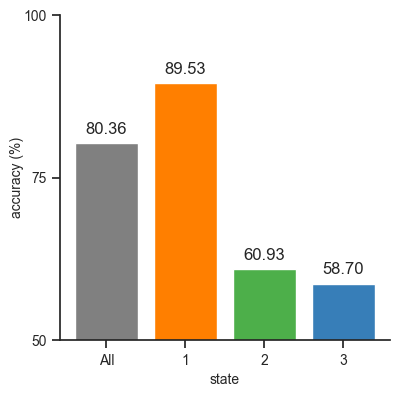

In [22]:
unnormalized_inpt, _, _ = load_data("IBL/CSHL_008" +
                                        '_unnormalized.npz')
accuracies_to_plot = []
not_zero_loc = np.where(unnormalized_inpt[:, 0] != 0)[0] # unnormalized input 

correct_ans = (np.sign(unnormalized_inpt[not_zero_loc, 0]) + 1) / 2
acc = np.sum(choices_mouse[not_zero_loc] == correct_ans) / len(correct_ans)
accuracies_to_plot.append(acc) # Append total accuracy

for state in range(n_states): # Append accuracy per state
    # index of time points where the most likely state is 0
    #idx_of_interest = np.where(model.decode_state(X_mouse,choices_mouse, state_format = "index")==state) 
    # viterbi yields a slightly different result
    
    posterior_probs = model.smooth_proba(X_mouse, choices_mouse)
    idx_of_interest = np.where(posterior_probs[:, state] >= 0.9)[0]
    
    inpt_this_state, unnormalized_inpt_this_state, y_this_state = \
        design_matrix[idx_of_interest, :], unnormalized_inpt[idx_of_interest, :], \
        choices_mouse[idx_of_interest]

    not_zero_loc = np.where(unnormalized_inpt_this_state[:, 0] != 0)[0]
    
    correct_ans = (np.sign(unnormalized_inpt_this_state[not_zero_loc, 0]) + 1) / 2
    acc = np.sum(y_this_state[not_zero_loc] == correct_ans) / len(correct_ans)
    accuracies_to_plot.append(acc)
    
cols = [
        '#ff7f00', '#4daf4a', '#377eb8', '#f781bf', '#a65628', '#984ea3',
        '#999999', '#e41a1c', '#dede00'
    ]

fig = plt.figure(figsize=(6, 5))
plt.subplots_adjust(left=0.4, bottom=0.3, right=0.95, top=0.95)
for z, acc in enumerate(accuracies_to_plot):
    if z == 0:
        col = 'grey'
    else:
        col = cols[z - 1]
    plt.bar(z, acc*100, width=0.8, color=col)
    plt.text(z, acc*100 + 1, f"{acc*100:.2f}", ha='center', va='bottom', fontsize=12)

plt.ylim((50, 100))
plt.xticks([0, 1, 2, 3], ['All', '1', '2', '3'], fontsize=10)
plt.yticks([50, 75, 100], fontsize=10)
plt.xlabel('state', fontsize=10)
plt.ylabel('accuracy (%)', fontsize=10, labelpad=-0.5)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.show()

### 3a. Posterior state probabilities
We can also show the posterior state probabilities

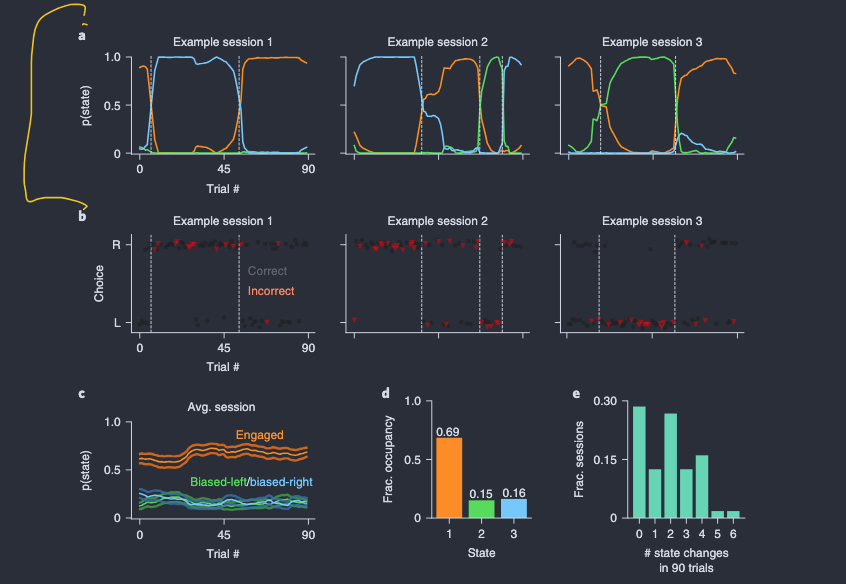

/Users/camilamaura/coding_projects/glm_hmm_notebook/.venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(


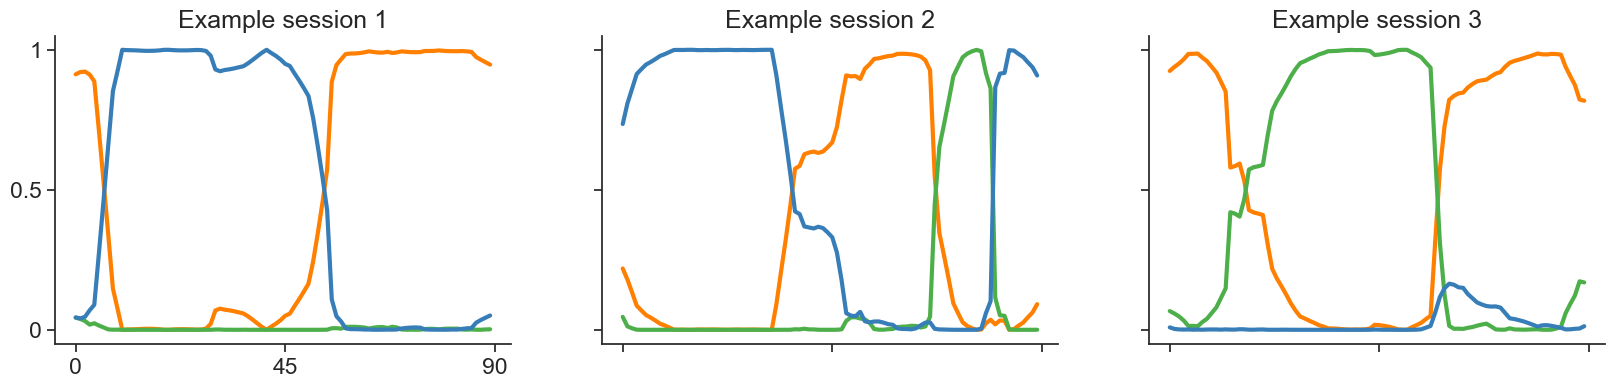

In [23]:
sess_to_plot = ["CSHL_008-2019-04-29-001", "CSHL_008-2019-08-07-001",
                    "CSHL_008-2019-05-28-001"]

sess_ex_1 = np.where(session == sess_to_plot[0])
sess_ex_2 = np.where(session == sess_to_plot[1])
sess_ex_3 = np.where(session == sess_to_plot[2])

sess_examples = [sess_ex_1, sess_ex_2, sess_ex_3]
posteriors = model.smooth_proba(X_mouse, choices_tsd)

colors =['#ff7f00', '#4daf4a', '#377eb8']
fig, ax = plt.subplots(1,3,figsize=(20, 4))
for example_session in range(len(ax)):
    for state in range(3):
        ax[example_session].plot(posteriors[sess_examples[example_session][0][0]:sess_examples[example_session][0][0]+90][:, state],
                    label="State " + str(state + 1), lw=3,
                    color=colors[state])
        ax[example_session].set_title("Example session " + str(example_session + 1))#, fontsize=10)
        if example_session == 0:
            ax[example_session].set_xticks(
                [
                    sess_examples[example_session][0][0], 
                    sess_examples[example_session][0][0] + 45, 
                    sess_examples[example_session][0][0] + 90
                ], 
                [
                    "0", 
                    "45", 
                    "90"
                ], 
            )
            ax[example_session].set_yticks(
                [0, 0.5, 1], 
                ["0", "0.5", "1"], 
            )
        else:
            ax[example_session].set_xticks(
                [
                    sess_examples[example_session][0][0], 
                    sess_examples[example_session][0][0] + 45, 
                    sess_examples[example_session][0][0] + 90
                ], 
                [
                    " ", 
                    " ", 
                    " "
                ], 
            )
            ax[example_session].set_yticks(
                [0, 0.5, 1], 
                [" ", " ", " "], 
            )

Ashwood text: ig. 3 | Inferred state dynamics for example IBL mouse. a, Posterior state probabilities for three example sessions, revealing high levels of certainty about the mouse’s internal state and showing that states typically persisted for many trials in a row. b, raw behavioral data corresponding to these three sessions. each dot corresponds to a single trial; the x position indicates the trial within the session, whereas the y position indicates if the mouse went rightward or leftward on the trial (y positions are slightly jittered for visibility). The dot’s color and shape indicates if the trial was an error or correct trial (red triangles correspond to errors, whereas black circles represent correct choices). All trials except 0% contrast trials (for which the correct answer is determined randomly) are shown here. The dashed vertical lines correspond to the location of state changes (obtained using the posterior probabilities shown in a). c, Average trajectories of state probabilities within a session, computed over 56 sessions. error bars indicate ± 1 s.e.m. d, Fractional occupancies for the three states across all trials. For this analysis, we assigned each trial to its most likely state and then counted the fraction of trials assigned to each state. Overall, the mouse spent 69% of all trials in the engaged state and 31% of trials in one of the two biased states. e, Histogram showing the number of inferred state changes per session for all 56 sessions of data for this mouse. Only 29% of sessions involved the mouse persisting in a single state for the entire 90-trial session. Frac., fractional.

## Fitting a GLM-HMM with NeMoS (MAP)


## 02. Understanding fitting: Hierarchical fitting process
Explanation of Ashwood fitting process.

I think it would be nice to showcase a small version of the hierarchical fitting process here, only because people using the tool might be interested in running similar analyses

## 03. Fitting the data
- Plot state probability against choices to show that in the state in which the animal considers the stimuli it performs better

## 04. Comparing results
1. Show weights, initial and transition proba recoveries
2. Show log likelihood
2. Benchmark with ssm

## Conclusion

## Other resources
- ssm tutorial

## References

<a id="ref1"></a><a href="#cite1a">[1a]</a> <a href="#cite1b">[1b]</a> <a href="#cite1c">[1c]</a> <a href="#cite1d">[1d]</a> Pillow, J. W., Shlens, J., Paninski, L., Sher, A., Litke, A. M., Chichilnisky, E. J., & Simoncelli, E. P. (2008). Spatio-temporal correlations and visual signalling in a complete neuronal population. Nature, 454(7207), 995-999. https://doi.org/10.1038/nature07140